In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix
import matplotlib.pyplot as plt


In [2]:
curve_df = pd.read_hdf('../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

groundtruth_df = pd.read_csv('../data/groundtruth_df.csv')
groundtruth_df['encoded_igi_call'] = 1*(groundtruth_df.igi_call == 'Positive')
groundtruth_df['groundtruth_label'] = 1*(groundtruth_df.groundtruth == 1)


In [3]:
fusion_vit_train_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_train_pred_df.csv')
fusion_vit_train_pred = (fusion_vit_train_pred
           .merge(groundtruth_df[['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates(), 
                  how='inner', on = 'curve_idx')
           .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1']].drop_duplicates(), 
                  how = 'inner', on = 'curve_idx'))
fusion_vit_train_pred = fusion_vit_train_pred.rename(columns={'prob':'outputs'})

In [4]:
fusion_vit_test_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_test_pred_df.csv')
fusion_vit_test_pred = (fusion_vit_test_pred
           .merge(groundtruth_df[['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates(), 
                  how='inner', on = 'curve_idx')
           .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1']].drop_duplicates(), 
                  how = 'inner', on = 'curve_idx'))
fusion_vit_test_pred = fusion_vit_test_pred.rename(columns={'prob':'outputs'})

In [5]:
fusion_outputs_train = pd.concat([fusion_vit_train_pred[~fusion_vit_train_pred.target.isin(['MS2','RnaseP'])], 
                                  fusion_vit_test_pred[~fusion_vit_test_pred.target.isin(['MS2','RnaseP'])]])

In [6]:
fusion_outputs_train = fusion_outputs_train[fusion_outputs_train.sample_type != 'Clinical Sample']
fusion_outputs_train['sample_label'] = 0
fusion_outputs_train.loc[fusion_outputs_train.sample_type == 'Negative Control (qPCR)', 'sample_label'] = 0
fusion_outputs_train.loc[fusion_outputs_train.sample_type == 'Positive Control (qPCR)', 'sample_label'] = 1
fusion_outputs_train.loc[fusion_outputs_train.sample_type == 'Human Negative Control (Extraction)', 'sample_label'] = 1


In [7]:
fusion_outputs_train['test_kit'] = fusion_outputs_train.groupby('sample_id').curve_idx.transform(lambda x: x.nunique())
fusion_outputs_train['test_kit'] = np.where(fusion_outputs_train.test_kit == 3, 'Thermo', 'LuNER')

In [8]:
fusion_outputs_train['target'] = fusion_outputs_train['target'].str.replace(' ', '_')
wide_output_df = pd.pivot_table(fusion_outputs_train, index=['sample_id','sample_label','test_kit'],
               values='outputs', columns='target').reset_index()


### GLM trained on train + test sets

In [10]:
thermo_glm = smf.glm(formula='sample_label ~ N_gene + ORF1ab + S_gene', 
        data=wide_output_df[wide_output_df.test_kit == 'Thermo'], 
        family=sm.families.Binomial())
thermo_result = thermo_glm.fit()

luner_glm = smf.glm(formula='sample_label ~ N_gene + E_gene', 
        data=wide_output_df[wide_output_df.test_kit == 'LuNER'], 
        family=sm.families.Binomial())
luner_result = luner_glm.fit()

/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1257: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1257: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1257: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/alpaca/anaconda3/envs/huong-pl/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1257: PerfectSeparationWarning: Perfect separation or predi

In [11]:
print(thermo_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           sample_label   No. Observations:                  266
Model:                            GLM   Df Residuals:                      262
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.5987e-09
Date:                Sat, 30 Dec 2023   Deviance:                   3.1974e-09
Time:                        23:04:14   Pearson chi2:                 1.60e-09
No. Iterations:                    31   Pseudo R-squ. (CS):             0.7386
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -539.4153   3.87e+05     -0.001      0.9

In [12]:
print(luner_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           sample_label   No. Observations:                  699
Model:                            GLM   Df Residuals:                      696
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1931e-09
Date:                Sat, 30 Dec 2023   Deviance:                   2.3856e-09
Time:                        23:04:14   Pearson chi2:                 1.19e-09
No. Iterations:                    26   Pseudo R-squ. (CS):             0.7380
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -31.7030   2.92e+04     -0.001      0.9

### Run GLM on retest

In [13]:
fusion_vit_retest_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_retest_pred_df.csv')
retest_df = (fusion_vit_retest_pred
 .merge(join_df[['sample_id','curve_idx','target','igi_call','final_patient_result','current_sample_result']].drop_duplicates(),
        how = 'inner', on = 'curve_idx'))

retest_df['encoded_igi_call'] = 1*(retest_df.igi_call == 'Positive')
retest_df['groundtruth_label'] = 0
retest_df.loc[retest_df.target.isin(['RnaseP','MS2']), 'groundtruth_label'] = 1
retest_df.loc[(~retest_df.target.isin(['RnaseP','MS2'])) & (retest_df.final_patient_result == 'Positive'), 'groundtruth_label'] = 1


best_acc_thres = 0.5657657657657658
retest_df['pred'] = retest_df.outputs >= best_acc_thres

In [14]:
retest_sample = retest_df.copy()

invalid_sample_id = retest_sample[(retest_sample.target.isin(['MS2','RnaseP'])) & (retest_sample.pred == 0)].sample_id

retest_sample_df = (retest_sample[~retest_sample.target.isin(['RnaseP','MS2'])]
                    .groupby(['sample_id','final_patient_result'])
                    .agg(sample_prob=('pred','mean'))
                    .reset_index())

retest_sample_df['igi_rule_pred'] = -1
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)),'igi_rule_pred'] = 0
retest_sample_df.loc[(retest_sample_df.sample_prob >= 0.5),'igi_rule_pred'] = 1


In [15]:
invalid_sample_id = retest_df[(retest_df.target.isin(['MS2','RnaseP'])) & (retest_df.pred == 0)].sample_id

retest_outputs = retest_df.copy()
retest_outputs = retest_outputs[~retest_outputs.target.isin(['RnaseP','MS2'])]
retest_outputs['test_kit'] = retest_outputs.groupby('sample_id').curve_idx.transform(lambda x: x.nunique())
retest_outputs['test_kit'] = np.where(retest_outputs.test_kit == 3, 'Thermo', 'LuNER')

retest_outputs['target'] = retest_outputs.target.str.replace(' ','_')

retest_outputs['sample_label'] = np.nan
retest_outputs.loc[retest_outputs.final_patient_result == 'Positive', 'sample_label'] = 1
retest_outputs.loc[retest_outputs.final_patient_result == 'Negative', 'sample_label'] = 0
retest_outputs.loc[retest_outputs.final_patient_result == 'ReSample', 'sample_label'] = -1

retest_outputs['sample_prob'] = retest_outputs[~retest_outputs.target.isin(['MS2','RnaseP'])].groupby('sample_id').pred.transform('mean')

retest_outputs['igi_rule_pred'] = -1
retest_outputs.loc[retest_outputs.sample_prob >= 0.5, 'igi_rule_pred'] = 1
retest_outputs.loc[(retest_outputs.sample_prob == 0) & (~retest_outputs.sample_id.isin(invalid_sample_id)), 'igi_rule_pred'] = 0


In [16]:
retest_outputs = pd.pivot_table(retest_outputs, index=['sample_id','sample_label','igi_rule_pred','test_kit'],
                                columns=['target'], values='outputs').reset_index()

retest_outputs['sample_pred'] = np.nan
retest_outputs.loc[retest_outputs.test_kit == 'Thermo', 'sample_pred'] = np.round(thermo_result.predict(retest_outputs.loc[retest_outputs.test_kit == 'Thermo']))
retest_outputs.loc[retest_outputs.test_kit == 'LuNER', 'sample_pred'] = np.round(luner_result.predict(retest_outputs.loc[retest_outputs.test_kit == 'LuNER']))

retest_outputs.loc[(retest_outputs.sample_pred == 0) & (retest_outputs.sample_id.isin(invalid_sample_id)), 'sample_pred'] = -1

Text(0.5, 1.0, 'IGI rule on sample classification')

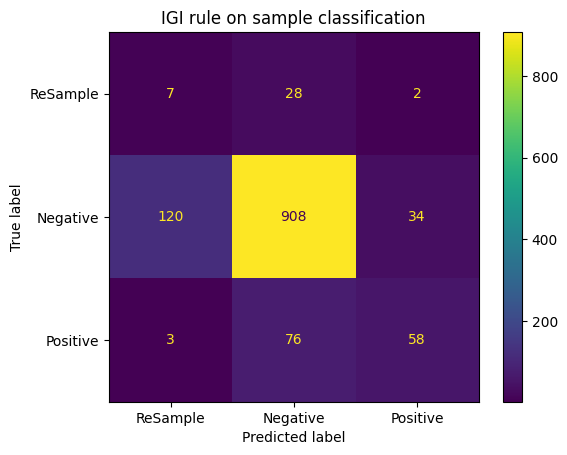

In [17]:
cm = confusion_matrix(retest_outputs.sample_label, retest_outputs.igi_rule_pred, labels = [-1, 0, 1])
ConfusionMatrixDisplay(cm, display_labels= ['ReSample','Negative','Positive']).plot()
plt.title('IGI rule on sample classification')


Text(0.5, 1.0, 'GLM on sample classification')

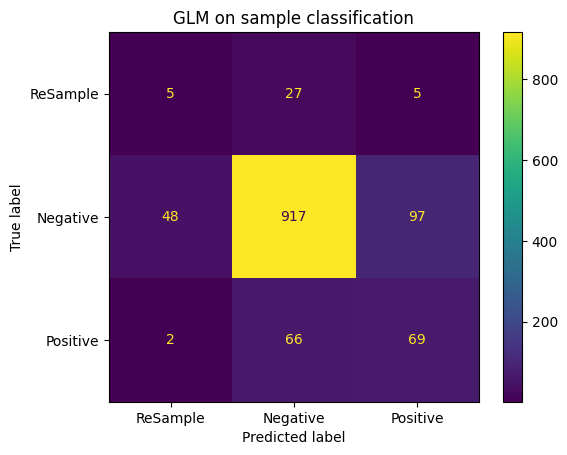

In [18]:
cm = confusion_matrix(retest_outputs.sample_label, retest_outputs.sample_pred, labels = [-1, 0, 1])
ConfusionMatrixDisplay(cm, display_labels= ['ReSample','Negative','Positive']).plot()
plt.title('GLM on sample classification')

In [54]:
retest_outputs.groupby(['test_kit', 'sample_label']).agg(pos = ('igi_rule_pred', lambda x: sum(1*(x == 1))/len(x)),
                                                    neg = ('igi_rule_pred', lambda x: sum(1*(x == 0))/len(x)),
                                                    resample = ('igi_rule_pred', lambda x: sum(1*(x == -1))/len(x)))

pos       neg  resample
test_kit sample_label                              
LuNER    -1.0          0.166667  0.583333  0.250000
          0.0          0.043417  0.911765  0.044818
          1.0          0.432836  0.552239  0.014925
Thermo   -1.0          0.000000  0.840000  0.160000
          0.0          0.008621  0.738506  0.252874
          1.0          0.000000  0.666667  0.333333

In [55]:
retest_outputs.groupby(['test_kit', 'sample_label']).agg(pos = ('sample_pred', lambda x: sum(1*(x == 1))/len(x)),
                                                    neg = ('sample_pred', lambda x: sum(1*(x == 0))/len(x)),
                                                    resample = ('sample_pred', lambda x: sum(1*(x == -1))/len(x)))

pos       neg  resample
test_kit sample_label                              
LuNER    -1.0          0.083333  0.666667  0.250000
          0.0          0.040616  0.914566  0.044818
          1.0          0.500000  0.485075  0.014925
Thermo   -1.0          0.160000  0.760000  0.080000
          0.0          0.195402  0.758621  0.045977
          1.0          0.666667  0.333333  0.000000

### Run GLM known dilution

In [19]:
# known dilution dataset
known_df = pd.read_csv('../data/known_dilution_data.csv')
known_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_known_pred_df.csv')

known_df.loc[:,['groundtruth_target']] = 1
known_df.loc[known_df.target == 'RnaseP',['groundtruth_target']] = 0

known_full = (known_df.merge(known_pred[['curve_idx','outputs']], on = 'curve_idx'))

known_pred_df = known_full[(known_full.cycle_no == 40) & (known_full.target!= 'RnaseP')]

known_pred_df['pred'] = 0
known_pred_df.loc[known_pred_df.outputs >= best_acc_thres, 'pred'] = 1
known_pred_df['sample_prob'] = known_pred_df[~known_pred_df.target.isin(['MS2','RnaseP'])].groupby('well_position').pred.transform('mean')

known_pred_df['sample_label'] = known_pred_df.groupby('well_position').groundtruth_target.transform('mean') 

invalid_wells = known_full[(known_full.target == 'RnaseP') & (known_full.outputs < best_acc_thres)].well_position.unique()

/tmp/ipykernel_1381805/1352771843.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  known_pred_df['pred'] = 0
/tmp/ipykernel_1381805/1352771843.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  known_pred_df['sample_prob'] = known_pred_df[~known_pred_df.target.isin(['MS2','RnaseP'])].groupby('well_position').pred.transform('mean')
/tmp/ipykernel_1381805/1352771843.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [20]:
known_pred_df['igi_rule_pred'] = -1
known_pred_df.loc[known_pred_df.sample_prob >= 0.5, 'igi_rule_pred'] = 1
known_pred_df.loc[(known_pred_df.sample_prob == 0) & (~known_pred_df.well_position.isin(invalid_wells)), 'igi_rule_pred'] = 0
known_pred_df['target'] = known_pred_df.target.str.replace(' ','_')

known_outputs = pd.pivot_table(known_pred_df, index=['well_position','sample_label','igi_rule_pred','dilution_level'],
                                columns=['target'], values='outputs').reset_index()

known_outputs['sample_pred'] = np.round(luner_result.predict(known_outputs))

/tmp/ipykernel_1381805/2892275085.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  known_pred_df['igi_rule_pred'] = -1
/tmp/ipykernel_1381805/2892275085.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  known_pred_df['target'] = known_pred_df.target.str.replace(' ','_')


In [21]:
print(known_outputs.groupby('dilution_level').agg(pos = ('sample_pred', lambda x: sum(1*(x >= 0.5))),
                                                    neg = ('sample_pred', lambda x: sum(1*(x < 0.5)))))

                pos  neg
dilution_level          
1                23    1
10               16    0
40                2    0
100              15    0
1000             16    0
10000             8    0
100000           15    0


In [48]:
print(known_outputs.groupby('dilution_level').agg(pos = ('igi_rule_pred', lambda x: sum(1*(x == 1))),
                                                    neg = ('igi_rule_pred', lambda x: sum(1*(x == 0)))))

                pos  neg
dilution_level          
1                24    0
10               16    0
40                2    0
100              15    0
1000             16    0
10000             8    0
100000           15    0


### Train GLM with train + test + retest set

In [41]:
wide_output_w_retest_df = pd.concat([wide_output_df, retest_outputs[retest_outputs.sample_label != -1]])

In [42]:
thermo_glm_w_retest = smf.glm(formula='sample_label ~ N_gene + ORF1ab + S_gene', 
        data=wide_output_w_retest_df[wide_output_w_retest_df.test_kit == 'Thermo'], 
        family=sm.families.Binomial())
thermo_result_w_retest = thermo_glm_w_retest.fit()

luner_glm_w_retest = smf.glm(formula='sample_label ~ N_gene + E_gene', 
        data=wide_output_w_retest_df[wide_output_w_retest_df.test_kit == 'LuNER'], 
        family=sm.families.Binomial())
luner_result_w_retest = luner_glm_w_retest.fit()

In [43]:
print(thermo_result_w_retest.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           sample_label   No. Observations:                  617
Model:                            GLM   Df Residuals:                      613
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -22.722
Date:                Sat, 30 Dec 2023   Deviance:                       45.444
Time:                        23:28:00   Pearson chi2:                     449.
No. Iterations:                     9   Pseudo R-squ. (CS):             0.5743
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.9222      0.893     -7.749      0.0

In [40]:
print(thermo_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           sample_label   No. Observations:                  266
Model:                            GLM   Df Residuals:                      262
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.5987e-09
Date:                Sat, 30 Dec 2023   Deviance:                   3.1974e-09
Time:                        23:26:38   Pearson chi2:                 1.60e-09
No. Iterations:                    31   Pseudo R-squ. (CS):             0.7386
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -539.4153   3.87e+05     -0.001      0.9

In [44]:
print(luner_result_w_retest.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           sample_label   No. Observations:                 1547
Model:                            GLM   Df Residuals:                     1544
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -326.43
Date:                Sat, 30 Dec 2023   Deviance:                       652.86
Time:                        23:30:21   Pearson chi2:                 1.36e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.5190
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.8608      0.124    -23.010      0.0

In [45]:
print(luner_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           sample_label   No. Observations:                  699
Model:                            GLM   Df Residuals:                      696
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1931e-09
Date:                Sat, 30 Dec 2023   Deviance:                   2.3856e-09
Time:                        23:31:06   Pearson chi2:                 1.19e-09
No. Iterations:                    26   Pseudo R-squ. (CS):             0.7380
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -31.7030   2.92e+04     -0.001      0.9

In [47]:
known_pred_df['igi_rule_pred'] = -1
known_pred_df.loc[known_pred_df.sample_prob >= 0.5, 'igi_rule_pred'] = 1
known_pred_df.loc[(known_pred_df.sample_prob == 0) & (~known_pred_df.well_position.isin(invalid_wells)), 'igi_rule_pred'] = 0
known_pred_df['target'] = known_pred_df.target.str.replace(' ','_')

known_outputs = pd.pivot_table(known_pred_df, index=['well_position','sample_label','igi_rule_pred','dilution_level'],
                                columns=['target'], values='outputs').reset_index()

known_outputs['sample_pred'] = np.round(luner_result.predict(known_outputs))

/tmp/ipykernel_1381805/1687142717.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  known_pred_df['igi_rule_pred'] = -1
/tmp/ipykernel_1381805/1687142717.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  known_pred_df['target'] = known_pred_df.target.str.replace(' ','_')
